# Proximal Policy Optimization (PPO): A Comprehensive Introduction

**A hands-on tutorial with theory and PyTorch implementation**

---

Proximal Policy Optimization (PPO), introduced by [Schulman et al. (2017)](https://arxiv.org/abs/1707.06347), is one of the most widely used reinforcement learning (RL) algorithms today. It powers systems ranging from OpenAI's Dota 2 agents to the fine-tuning of large language models via RLHF (Reinforcement Learning from Human Feedback).

PPO's popularity comes from a rare combination: it is **simple to implement**, **sample-efficient enough for many problems**, and **robust** — it tends to "just work" across a wide range of environments without heavy hyperparameter tuning.

## What you will learn

1. The **theoretical foundations**: policy gradients, the objective PPO is approximating, and why naive policy gradients fail.
2. The **PPO objective**: the clipped surrogate and why clipping works.
3. **Generalized Advantage Estimation (GAE)**, an integral companion to PPO.
4. A **from-scratch PyTorch implementation** that trains on CartPole-v1.
5. **Strengths, weaknesses, and connections** to TRPO, A2C, DDPG, SAC, and RLHF.

## Notebook outline

1. RL background and notation
2. Policy gradient theorem & REINFORCE
3. Actor-critic and advantage functions
4. TRPO: the trust-region predecessor
5. The PPO clipped surrogate objective
6. Generalized Advantage Estimation (GAE)
7. Full PyTorch implementation on CartPole
8. Training and results
9. Strengths, weaknesses, practical tips
10. Connections to other algorithms
11. References


## 0. Setup

We'll use PyTorch as the deep learning framework and `gymnasium` (the maintained fork of OpenAI Gym) for environments. If you don't have these installed, uncomment the install cell.

In [1]:
# !pip install torch gymnasium matplotlib numpy

In [2]:
import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

import gymnasium as gym
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cpu
PyTorch version: 2.11.0


## 1. Reinforcement Learning Background

### 1.1 The Markov Decision Process

Reinforcement learning problems are modeled as a **Markov Decision Process (MDP)**, defined by the tuple $(\mathcal{S}, \mathcal{A}, P, r, \gamma, \rho_0)$:

- $\mathcal{S}$: set of **states**
- $\mathcal{A}$: set of **actions**
- $P(s' \mid s, a)$: **transition dynamics** — probability of next state given $(s, a)$
- $r(s, a)$: **reward function**
- $\gamma \in [0, 1)$: **discount factor**
- $\rho_0$: distribution over initial states

An agent interacts with the environment by following a **policy** $\pi(a \mid s)$, generating trajectories $\tau = (s_0, a_0, r_0, s_1, a_1, r_1, \dots)$.

### 1.2 The objective

The goal is to find a policy $\pi_\theta$ (parameterized by $\theta$) that maximizes the **expected discounted return**:

$$
J(\theta) \;=\; \mathbb{E}_{\tau \sim \pi_\theta}\!\left[\sum_{t=0}^{\infty} \gamma^t\, r(s_t, a_t)\right].
$$

### 1.3 Value functions

- **State-value**: $V^\pi(s) = \mathbb{E}_\pi\big[\sum_{k \geq 0} \gamma^k r_{t+k} \mid s_t = s\big]$
- **Action-value**: $Q^\pi(s, a) = \mathbb{E}_\pi\big[\sum_{k \geq 0} \gamma^k r_{t+k} \mid s_t = s, a_t = a\big]$
- **Advantage**: $A^\pi(s, a) = Q^\pi(s, a) - V^\pi(s)$

The advantage function is central to PPO — it measures "how much better is action $a$ than the policy's average behavior in state $s$."


## 2. Policy Gradient Methods

### 2.1 The Policy Gradient Theorem

Rather than learning a value function and deriving a policy (as in Q-learning), **policy gradient methods** directly parameterize $\pi_\theta$ and ascend $\nabla_\theta J(\theta)$.

The **Policy Gradient Theorem** (Sutton et al., 1999) states:

$$
\nabla_\theta J(\theta) \;=\; \mathbb{E}_{\tau \sim \pi_\theta}\!\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t \mid s_t)\, \Psi_t \right],
$$

where $\Psi_t$ can be various quantities (return, advantage, TD error…). A common choice is the advantage $A^\pi(s_t, a_t)$, which has lower variance than the raw return.

### 2.2 REINFORCE

The simplest policy gradient algorithm is **REINFORCE** (Williams, 1992), which uses the Monte Carlo return $G_t = \sum_{k \geq 0} \gamma^k r_{t+k}$ as $\Psi_t$:

$$
\nabla_\theta J(\theta) \approx \frac{1}{N}\sum_{i=1}^{N}\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t^{(i)} \mid s_t^{(i)})\, G_t^{(i)}.
$$

**Problems with vanilla REINFORCE:**
1. **High variance** — Monte Carlo returns fluctuate wildly.
2. **Sample inefficient** — each trajectory is used for exactly one gradient update, then thrown away (on-policy).
3. **No step-size control** — a single bad gradient update can destroy the policy and the agent may never recover, since future data is collected by a bad policy.

PPO addresses issues 2 and 3 directly; issue 1 is mitigated by combining PPO with a learned critic (next section).


## 3. Actor-Critic & the Advantage Function

Instead of using raw returns $G_t$, we estimate the advantage using a learned **critic** $V_\phi(s) \approx V^\pi(s)$.

A simple one-step estimator is the **TD error**:
$$
\hat{A}_t \;=\; r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t).
$$

This is low-variance but biased (because $V_\phi$ is learned). The opposite extreme is the Monte Carlo estimator $\hat{A}_t = G_t - V_\phi(s_t)$, which is high-variance but unbiased.

**Generalized Advantage Estimation (GAE)** (Schulman et al., 2015b) interpolates between these extremes with a parameter $\lambda \in [0, 1]$:

$$
\hat{A}^{\text{GAE}(\gamma, \lambda)}_t \;=\; \sum_{l=0}^{\infty} (\gamma \lambda)^l \delta_{t+l}, \qquad \delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t).
$$

- $\lambda = 0 \Rightarrow \hat{A}_t = \delta_t$ (one-step TD, low variance, high bias)
- $\lambda = 1 \Rightarrow \hat{A}_t = G_t - V_\phi(s_t)$ (Monte Carlo, high variance, low bias)

In practice $\lambda \in [0.9, 0.97]$ works well. PPO is almost always used together with GAE.


## 4. Trust Region Policy Optimization (TRPO)

PPO was designed as a simpler alternative to **TRPO** (Schulman et al., 2015a). Understanding TRPO's goals makes PPO's design crystal clear.

### 4.1 The surrogate objective

A central trick in policy optimization is **importance sampling**. Instead of estimating $J(\theta)$ directly (which would require fresh samples after every update), we express the improvement of a new policy $\pi_\theta$ over an old policy $\pi_{\theta_\text{old}}$ as:

$$
L^{\text{IS}}(\theta) \;=\; \mathbb{E}_{s, a \sim \pi_{\theta_\text{old}}}\!\left[\frac{\pi_\theta(a \mid s)}{\pi_{\theta_\text{old}}(a \mid s)}\, \hat{A}_t\right].
$$

Defining $r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_\text{old}}(a_t \mid s_t)}$, this becomes $\mathbb{E}_t[r_t(\theta) \hat{A}_t]$. This objective **reuses old data**, letting us do many gradient steps per batch of trajectories — the key to sample efficiency.

### 4.2 The problem

The surrogate $L^{\text{IS}}$ is only a good approximation of true improvement when $\pi_\theta$ is close to $\pi_{\theta_\text{old}}$. If we optimize $L^{\text{IS}}$ freely, the ratio $r_t(\theta)$ can become arbitrarily large, and the approximation breaks down — often catastrophically.

### 4.3 TRPO's answer

TRPO solves a constrained optimization problem:

$$
\max_\theta\; \mathbb{E}_t[r_t(\theta) \hat{A}_t] \quad \text{subject to} \quad \mathbb{E}_t\!\left[\mathrm{KL}\!\left(\pi_{\theta_\text{old}}(\cdot \mid s_t)\,\|\,\pi_\theta(\cdot \mid s_t)\right)\right] \leq \delta.
$$

This works but is complex: TRPO needs to compute Fisher–vector products via conjugate gradient and do a line search. PPO's question was: *can we get TRPO-like stability with a first-order, easy-to-implement method?*


## 5. PPO: The Clipped Surrogate Objective

### 5.1 The idea

Instead of constraining the KL divergence explicitly, PPO modifies the objective so that moving the probability ratio $r_t(\theta)$ too far away from 1 yields **no additional benefit**. This is achieved by **clipping**.

The PPO-Clip objective is:

$$
\boxed{\,L^{\text{CLIP}}(\theta) \;=\; \mathbb{E}_t\!\left[\min\!\Big(\, r_t(\theta)\,\hat{A}_t,\; \operatorname{clip}(r_t(\theta),\, 1-\epsilon,\, 1+\epsilon)\,\hat{A}_t\,\Big)\right]\,}
$$

where $\epsilon$ is a small hyperparameter, typically $0.1$ or $0.2$.

### 5.2 Unpacking the clip

Let's reason case by case:

- **When $\hat{A}_t > 0$** (action was better than average): the objective rewards increasing $r_t(\theta)$, but caps at $(1 + \epsilon)\hat{A}_t$. So the gradient vanishes once $r_t(\theta) > 1 + \epsilon$ — no incentive to push the action's probability even higher.
- **When $\hat{A}_t < 0$** (action was worse than average): the objective rewards decreasing $r_t(\theta)$, but caps at $(1 - \epsilon)\hat{A}_t$. So the gradient vanishes once $r_t(\theta) < 1 - \epsilon$.

The `min` ensures the clipped objective is a **pessimistic (lower) bound** on the unclipped one — we only ignore changes that would be overly optimistic.

### 5.3 Full PPO loss

The practical objective also includes a value-function loss and an entropy bonus (to encourage exploration):

$$
L^{\text{PPO}}(\theta, \phi) \;=\; \mathbb{E}_t\!\left[L^{\text{CLIP}}(\theta) \;-\; c_1\, (V_\phi(s_t) - V_t^{\text{target}})^2 \;+\; c_2\, \mathcal{H}[\pi_\theta](s_t)\right].
$$

- $c_1$ (typically 0.5) weights the value loss.
- $c_2$ (typically 0.01) weights the entropy bonus.
- $V_t^{\text{target}} = \hat{A}_t + V_\phi(s_t)$ is the bootstrapped return target.

### 5.4 Algorithm

```
for iteration = 1, 2, ... do
    Collect T timesteps of experience using π_θ_old in parallel envs
    Compute rewards-to-go and GAE advantages Â_t using V_φ
    for epoch = 1, ..., K do
        for minibatch in batch do
            Compute L^PPO
            Update θ, φ by SGD on L^PPO
    θ_old ← θ
```

Typical hyperparameters: $K = 3$–$10$ epochs, $\epsilon = 0.2$, $\gamma = 0.99$, $\lambda = 0.95$.

### 5.5 Visualizing the clipped objective

Let's plot $L^{\text{CLIP}}$ as a function of $r_t(\theta)$ for both positive and negative advantages.

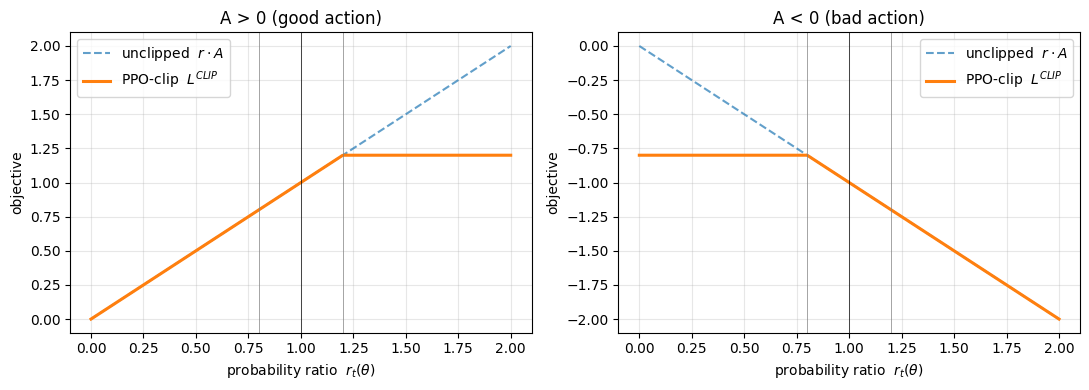

In [3]:
# Visualize the PPO-clip surrogate as a function of the probability ratio r.
eps = 0.2
r = np.linspace(0.0, 2.0, 400)

def ppo_clip(r, A, eps):
    return np.minimum(r * A, np.clip(r, 1 - eps, 1 + eps) * A)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, A, title in zip(axes, [1.0, -1.0], ["A > 0 (good action)", "A < 0 (bad action)"]):
    ax.plot(r, r * A, "--", label=r"unclipped  $r \cdot A$", alpha=0.7)
    ax.plot(r, ppo_clip(r, A, eps), lw=2.2, label=r"PPO-clip  $L^{CLIP}$")
    ax.axvline(1 - eps, color="gray", lw=0.5)
    ax.axvline(1 + eps, color="gray", lw=0.5)
    ax.axvline(1.0, color="black", lw=0.5)
    ax.set_xlabel(r"probability ratio  $r_t(\theta)$")
    ax.set_ylabel("objective")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Reading the plots:**
- **Left (A > 0):** increasing $r$ helps, but the clipped objective caps at $r = 1 + \epsilon$. Beyond that, there is no reward — so gradient descent won't push the ratio further.
- **Right (A < 0):** decreasing $r$ helps, but caps at $r = 1 - \epsilon$. However, note that if the ratio is already pushed in the *wrong* direction (e.g., $r$ large for a bad action), the unclipped term is used — the `min` means PPO *will* try to undo bad updates.

This asymmetric behavior — pessimistic when things look too rosy, still corrective when things go wrong — is the heart of PPO's empirical robustness.


## 6. Implementation in PyTorch

We now implement PPO from scratch and train it on `CartPole-v1`. The implementation has four components:

1. An **actor-critic network** sharing no parameters (simpler to reason about).
2. A **rollout buffer** storing $T$ steps of experience.
3. A **GAE** computation.
4. The **PPO update** with minibatches and multiple epochs.

### 6.1 Hyperparameters

In [4]:
@dataclass
class PPOConfig:
    # Environment
    env_id: str = "CartPole-v1"
    num_envs: int = 8            # parallel environments
    # Rollout
    rollout_steps: int = 128     # T, steps per env before an update
    total_timesteps: int = 50_000
    # Optimization
    lr: float = 3e-4
    num_epochs: int = 4          # K, gradient epochs per rollout
    num_minibatches: int = 4
    # Returns / advantages
    gamma: float = 0.99
    gae_lambda: float = 0.95
    # PPO clipping
    clip_eps: float = 0.2
    # Loss coefficients
    vf_coef: float = 0.5         # c1
    ent_coef: float = 0.01       # c2
    max_grad_norm: float = 0.5
    # Misc
    normalize_advantages: bool = True

cfg = PPOConfig()
cfg.batch_size = cfg.num_envs * cfg.rollout_steps
cfg.minibatch_size = cfg.batch_size // cfg.num_minibatches
print(cfg)


PPOConfig(env_id='CartPole-v1', num_envs=8, rollout_steps=128, total_timesteps=50000, lr=0.0003, num_epochs=4, num_minibatches=4, gamma=0.99, gae_lambda=0.95, clip_eps=0.2, vf_coef=0.5, ent_coef=0.01, max_grad_norm=0.5, normalize_advantages=True)


### 6.2 Actor-critic network

For CartPole the observation is a 4-d vector and there are 2 discrete actions. A small MLP suffices. Separate heads for policy logits and value estimate.

In [5]:
def layer_init(layer, std=math.sqrt(2), bias_const=0.0):
    '''Orthogonal init with a tuned gain — a small but impactful PPO implementation detail.'''
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden: int = 64):
        super().__init__()
        # Critic
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, 1), std=1.0),
        )
        # Actor
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, n_actions), std=0.01),  # small std on last layer
        )

    def get_value(self, x):
        return self.critic(x).squeeze(-1)

    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        dist = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(x).squeeze(-1)


**Implementation notes**

- **Orthogonal initialization** with specific gains (`sqrt(2)` for hidden layers, `0.01` for the policy head, `1.0` for the value head) is a staple of stable PPO implementations — it keeps initial policies near-uniform and value estimates near zero. See Engstrom et al. (2020) and Andrychowicz et al. (2021) for empirical studies of such details.
- **`tanh` activations** are standard in PPO code bases; ReLU also works but tanh pairs well with orthogonal init.

### 6.3 Rollout buffer

During a rollout we collect `rollout_steps × num_envs` transitions, storing observations, actions, log-probs, values, rewards, and terminal flags.

In [6]:
class RolloutBuffer:
    def __init__(self, cfg, obs_shape, action_shape, device):
        T, N = cfg.rollout_steps, cfg.num_envs
        self.obs      = torch.zeros((T, N) + obs_shape, device=device)
        self.actions  = torch.zeros((T, N) + action_shape, dtype=torch.long, device=device)
        self.logprobs = torch.zeros((T, N), device=device)
        self.rewards  = torch.zeros((T, N), device=device)
        self.dones    = torch.zeros((T, N), device=device)
        self.values   = torch.zeros((T, N), device=device)
        self.cfg = cfg
        self.device = device

    def compute_gae(self, last_value, last_done):
        '''Generalized Advantage Estimation, computed backwards in time.

        δ_t = r_t + γ V(s_{t+1})(1 - done_{t+1}) - V(s_t)
        A_t = δ_t + γ λ (1 - done_{t+1}) A_{t+1}
        '''
        T = self.cfg.rollout_steps
        advantages = torch.zeros_like(self.rewards)
        gae = 0.0
        for t in reversed(range(T)):
            if t == T - 1:
                next_non_terminal = 1.0 - last_done.float()
                next_value = last_value
            else:
                next_non_terminal = 1.0 - self.dones[t + 1]
                next_value = self.values[t + 1]
            delta = self.rewards[t] + self.cfg.gamma * next_value * next_non_terminal - self.values[t]
            gae = delta + self.cfg.gamma * self.cfg.gae_lambda * next_non_terminal * gae
            advantages[t] = gae
        returns = advantages + self.values
        return advantages, returns


### 6.4 The PPO update

This is the core PPO step — clipped policy loss, value loss, entropy bonus, minibatched over several epochs.

In [7]:
def ppo_update(agent, optimizer, cfg,
               b_obs, b_actions, b_logprobs, b_advantages, b_returns, b_values):
    '''One PPO update: K epochs over the full batch, split into M minibatches.'''
    batch_size = b_obs.shape[0]
    inds = np.arange(batch_size)

    losses = {"policy": [], "value": [], "entropy": [], "approx_kl": [], "clip_frac": []}

    for epoch in range(cfg.num_epochs):
        np.random.shuffle(inds)
        for start in range(0, batch_size, cfg.minibatch_size):
            mb = inds[start : start + cfg.minibatch_size]

            _, new_logprob, entropy, new_value = agent.get_action_and_value(
                b_obs[mb], b_actions[mb]
            )

            # Probability ratio r_t(θ) = π_θ(a|s) / π_θ_old(a|s)
            log_ratio = new_logprob - b_logprobs[mb]
            ratio = log_ratio.exp()

            # Advantage normalization — a common stabilizing trick
            mb_adv = b_advantages[mb]
            if cfg.normalize_advantages:
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

            # --- Policy loss (clipped surrogate) ---
            pg_loss1 = -mb_adv * ratio
            pg_loss2 = -mb_adv * torch.clamp(ratio, 1 - cfg.clip_eps, 1 + cfg.clip_eps)
            policy_loss = torch.max(pg_loss1, pg_loss2).mean()
            # Note: we maximize L^CLIP, which equals minimizing -L^CLIP. Using
            # max of negatives is equivalent to min of positives in the original form.

            # --- Value loss (simple MSE; some codebases clip this too) ---
            value_loss = 0.5 * ((new_value - b_returns[mb]) ** 2).mean()

            # --- Entropy bonus ---
            entropy_loss = entropy.mean()

            loss = policy_loss + cfg.vf_coef * value_loss - cfg.ent_coef * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), cfg.max_grad_norm)
            optimizer.step()

            # Diagnostics
            with torch.no_grad():
                # Approximate KL (Schulman's unbiased estimator — see his blog post)
                approx_kl = ((ratio - 1) - log_ratio).mean().item()
                clip_frac = ((ratio - 1.0).abs() > cfg.clip_eps).float().mean().item()

            losses["policy"].append(policy_loss.item())
            losses["value"].append(value_loss.item())
            losses["entropy"].append(entropy_loss.item())
            losses["approx_kl"].append(approx_kl)
            losses["clip_frac"].append(clip_frac)

    return {k: float(np.mean(v)) for k, v in losses.items()}


### 6.5 The training loop

We use `gymnasium.vector.SyncVectorEnv` to run `num_envs` copies of CartPole in parallel — this is *crucial* for on-policy methods because each gradient update requires fresh data and batching across envs dramatically improves throughput.

In [8]:
def make_env(env_id, seed, idx):
    def thunk():
        env = gym.make(env_id)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env.action_space.seed(seed + idx)
        return env
    return thunk

def train_ppo(cfg: PPOConfig, verbose: bool = True):
    envs = gym.vector.SyncVectorEnv([make_env(cfg.env_id, SEED, i) for i in range(cfg.num_envs)])
    obs_shape = envs.single_observation_space.shape
    n_actions = envs.single_action_space.n

    agent = ActorCritic(obs_shape[0], n_actions).to(device)
    optimizer = torch.optim.Adam(agent.parameters(), lr=cfg.lr, eps=1e-5)
    buffer = RolloutBuffer(cfg, obs_shape, action_shape=(), device=device)

    obs_np, _ = envs.reset(seed=SEED)
    next_obs = torch.as_tensor(obs_np, dtype=torch.float32, device=device)
    next_done = torch.zeros(cfg.num_envs, device=device)

    num_updates = cfg.total_timesteps // cfg.batch_size
    episode_returns: List[float] = []
    log_rows = []

    global_step = 0
    for update in range(1, num_updates + 1):
        # ---- 1. Collect rollout ----
        for t in range(cfg.rollout_steps):
            global_step += cfg.num_envs
            buffer.obs[t] = next_obs
            buffer.dones[t] = next_done

            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
            buffer.actions[t] = action
            buffer.logprobs[t] = logprob
            buffer.values[t] = value

            obs_np, reward, terminated, truncated, info = envs.step(action.cpu().numpy())
            done = np.logical_or(terminated, truncated)
            buffer.rewards[t] = torch.as_tensor(reward, dtype=torch.float32, device=device)
            next_obs = torch.as_tensor(obs_np, dtype=torch.float32, device=device)
            next_done = torch.as_tensor(done, dtype=torch.float32, device=device)

            # Log completed episodes via RecordEpisodeStatistics
            if "final_info" in info:
                for item in info["final_info"]:
                    if item is not None and "episode" in item:
                        episode_returns.append(float(item["episode"]["r"]))
            elif "episode" in info:  # gymnasium >=1.0 vectorized format
                ep_done_mask = info.get("_episode", np.zeros(cfg.num_envs, dtype=bool))
                for i, d in enumerate(ep_done_mask):
                    if d:
                        episode_returns.append(float(info["episode"]["r"][i]))

        # ---- 2. Compute GAE ----
        with torch.no_grad():
            last_value = agent.get_value(next_obs)
        advantages, returns = buffer.compute_gae(last_value, next_done)

        # ---- 3. Flatten batch ----
        b_obs       = buffer.obs.reshape((-1,) + obs_shape)
        b_actions   = buffer.actions.reshape(-1)
        b_logprobs  = buffer.logprobs.reshape(-1)
        b_advantages = advantages.reshape(-1)
        b_returns   = returns.reshape(-1)
        b_values    = buffer.values.reshape(-1)

        # ---- 4. PPO update ----
        stats = ppo_update(agent, optimizer, cfg,
                           b_obs, b_actions, b_logprobs, b_advantages, b_returns, b_values)

        mean_return = float(np.mean(episode_returns[-20:])) if episode_returns else float("nan")
        log_rows.append({"step": global_step, "mean_return": mean_return, **stats})

        if verbose and (update % 5 == 0 or update == 1):
            print(f"upd {update:3d} | steps {global_step:6d} | "
                  f"ret(last 20) {mean_return:6.1f} | "
                  f"pg {stats['policy']:+.3f} | v {stats['value']:.3f} | "
                  f"ent {stats['entropy']:.3f} | KL {stats['approx_kl']:.4f} | "
                  f"clip {stats['clip_frac']:.2f}")

    envs.close()
    return agent, episode_returns, log_rows


## 7. Training on CartPole

CartPole is solved when the episode return (= episode length) approaches 500. With the hyperparameters above, PPO typically reaches this in 30–50k environment steps.

In [9]:
agent, ep_returns, logs = train_ppo(cfg, verbose=True)

upd   1 | steps   1024 | ret(last 20)   23.4 | pg -0.003 | v 45.074 | ent 0.693 | KL 0.0003 | clip 0.00
upd   5 | steps   5120 | ret(last 20)   38.9 | pg -0.003 | v 60.139 | ent 0.670 | KL 0.0005 | clip 0.00
upd  10 | steps  10240 | ret(last 20)   43.6 | pg -0.003 | v 56.748 | ent 0.624 | KL 0.0002 | clip 0.00
upd  15 | steps  15360 | ret(last 20)   57.9 | pg -0.002 | v 65.440 | ent 0.613 | KL 0.0001 | clip 0.00
upd  20 | steps  20480 | ret(last 20)   95.1 | pg -0.002 | v 57.087 | ent 0.611 | KL 0.0003 | clip 0.00
upd  25 | steps  25600 | ret(last 20)  137.2 | pg -0.002 | v 60.864 | ent 0.583 | KL 0.0002 | clip 0.00
upd  30 | steps  30720 | ret(last 20)  154.2 | pg -0.004 | v 70.253 | ent 0.577 | KL 0.0006 | clip 0.00
upd  35 | steps  35840 | ret(last 20)  260.7 | pg +0.000 | v 62.282 | ent 0.580 | KL 0.0001 | clip 0.00
upd  40 | steps  40960 | ret(last 20)  238.1 | pg -0.001 | v 59.613 | ent 0.559 | KL 0.0003 | clip 0.00
upd  45 | steps  46080 | ret(last 20)  301.8 | pg +0.000 | v 60.

### 7.1 Learning curve

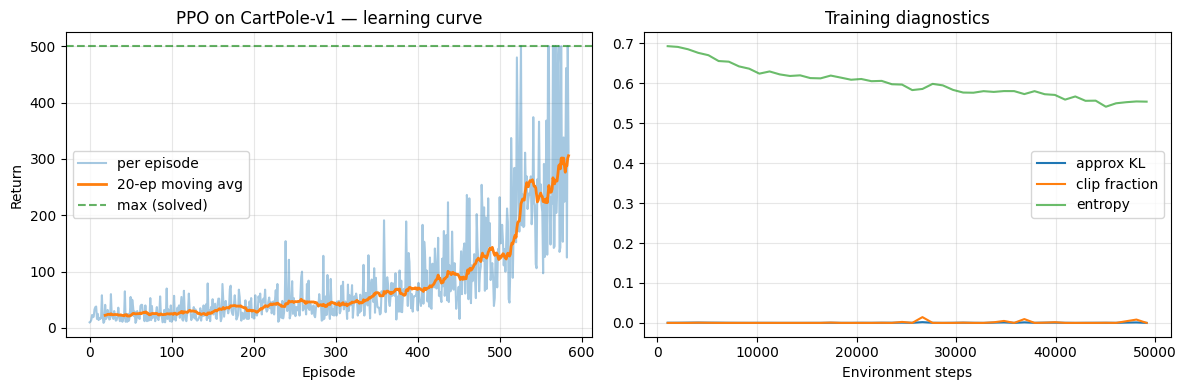

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Episode return curve
axes[0].plot(ep_returns, alpha=0.4, label="per episode")
if len(ep_returns) >= 20:
    smooth = np.convolve(ep_returns, np.ones(20) / 20, mode="valid")
    axes[0].plot(np.arange(len(smooth)) + 19, smooth, lw=2, label="20-ep moving avg")
axes[0].axhline(500, color="green", ls="--", alpha=0.6, label="max (solved)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Return")
axes[0].set_title("PPO on CartPole-v1 — learning curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Diagnostics: KL and clip fraction
steps = [row["step"] for row in logs]
axes[1].plot(steps, [row["approx_kl"] for row in logs], label="approx KL")
axes[1].plot(steps, [row["clip_frac"] for row in logs], label="clip fraction")
axes[1].plot(steps, [row["entropy"] for row in logs], label="entropy", alpha=0.7)
axes[1].set_xlabel("Environment steps")
axes[1].set_title("Training diagnostics")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**What to look for in the diagnostics:**

- **Approximate KL** between $\pi_\theta$ and $\pi_{\theta_\text{old}}$ should stay small (roughly $< 0.02$). If it blows up, the clip range is too loose or the learning rate too high.
- **Clip fraction** is the proportion of samples whose ratio falls outside $[1-\epsilon, 1+\epsilon]$. Typical values are $0.1$–$0.3$. A near-zero clip fraction means clipping is inactive (you could probably take larger steps); a very high clip fraction means your updates are consistently hitting the trust-region boundary.
- **Entropy** should decrease gradually as the policy becomes more deterministic. A rapid collapse suggests premature convergence; tune `ent_coef` up.

### 7.2 Evaluating the trained policy

In [11]:
def evaluate(agent, env_id="CartPole-v1", n_episodes=10, seed=123):
    env = gym.make(env_id)
    returns = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            with torch.no_grad():
                obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                # Greedy action: argmax of logits
                logits = agent.actor(obs_t)
                action = int(logits.argmax(dim=-1).item())
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_ret += reward
        returns.append(ep_ret)
    env.close()
    return returns

eval_returns = evaluate(agent)
print(f"Eval returns over 10 episodes: {eval_returns}")
print(f"Mean: {np.mean(eval_returns):.1f}  Std: {np.std(eval_returns):.1f}")


Eval returns over 10 episodes: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Mean: 500.0  Std: 0.0


## 8. Strengths and Weaknesses of PPO

### Strengths

- **Simplicity of implementation.** The core update is a handful of lines — no conjugate gradients, no Hessian-vector products.
- **Robustness.** PPO is famously forgiving of hyperparameters. The default $\epsilon = 0.2$, $\gamma = 0.99$, $\lambda = 0.95$ works across a surprisingly wide range of tasks.
- **Scalability & parallelism.** Rollouts are independent across environments, making PPO trivially parallelizable (this is why it scaled to OpenAI Five / Dota 2).
- **Works for both discrete and continuous actions.** Swap `Categorical` for `Normal` (or `TanhNormal`) and the same algorithm applies to continuous control.
- **Minimal assumptions.** Unlike DDPG/SAC, PPO does not require a reparameterizable policy or an off-policy replay buffer. It also fits RLHF beautifully — language models' policies are categorical over tokens, and KL-to-reference penalties slot in naturally.

### Weaknesses

- **Sample inefficiency.** PPO is on-policy: every gradient update must be followed by fresh rollouts. Off-policy methods (SAC, TD3) can be 10–100× more sample-efficient on continuous-control tasks.
- **Sensitive to implementation details.** Despite the "robust" reputation, many small choices matter: observation normalization, reward scaling, orthogonal init, advantage normalization, learning-rate annealing, value-loss clipping. Engstrom et al. (2020) show that "code-level" choices can dominate the algorithmic ones.
- **Clipped objective is heuristic.** The clip does not explicitly bound the KL divergence; pathological inputs can still produce large distribution shifts. In practice this rarely matters, but it means PPO lacks TRPO's monotonic improvement guarantee.
- **Exploration is weak.** Exploration comes only from the entropy bonus and policy stochasticity. For hard-exploration tasks (Montezuma's Revenge, etc.) PPO needs to be augmented with intrinsic motivation or curiosity.
- **Hyperparameter $\epsilon$ is not adaptive.** If the optimal step size varies across training, a fixed clip range can be suboptimal. Adaptive-KL PPO (the "KL-penalty" variant) addresses this but is less common in practice.

### Practical tips (if PPO is misbehaving)

- **Normalize observations and rewards** (running mean/std). Huge effect on environments with varying state/reward scales.
- **Clip the value function loss** similarly to the policy: $L^V = \max((V_\phi - V^{\text{target}})^2, (V_\phi^{\text{clip}} - V^{\text{target}})^2)$.
- **Anneal the learning rate** linearly to zero over training.
- **Watch approximate KL**: if it exceeds ~0.02 regularly, reduce LR or number of epochs. A common heuristic is **early-stopping** the epoch loop if KL exceeds a threshold.
- **Use multiple parallel environments** — it's free variance reduction.


## 9. Connections to Other Algorithms

PPO sits in the middle of a rich family tree.

### Predecessors

- **REINFORCE** (Williams, 1992): vanilla policy gradient with Monte Carlo returns. PPO = REINFORCE + critic + importance sampling + clipping + many gradient steps per batch.
- **A2C / A3C** (Mnih et al., 2016): synchronous/asynchronous advantage actor-critic. A2C ≈ PPO with a *single* gradient step per batch and no clipping. PPO can be viewed as "A2C with many safe SGD steps per rollout."
- **TRPO** (Schulman et al., 2015a): the explicit trust-region method PPO approximates with a simple first-order clip.

### Contemporaries / alternatives

- **DDPG** (Lillicrap et al., 2016), **TD3** (Fujimoto et al., 2018), **SAC** (Haarnoja et al., 2018): off-policy actor-critic methods for continuous control. More sample-efficient than PPO but more fragile; they rely on replay buffers and target networks. SAC additionally optimizes entropy to trade off exploration and exploitation automatically.
- **IMPALA** (Espeholt et al., 2018), **V-trace**: distributed off-policy correction for very large-scale actor-critic. Solves some of PPO's sample-efficiency issues in the distributed setting.

### Descendants

- **PPG** (Phasic Policy Gradient, Cobbe et al., 2020): alternates "policy phase" and "auxiliary phase" updates to decouple actor and critic training.
- **DAPO / GRPO**: used in modern LLM post-training. **GRPO** (Group Relative Policy Optimization, used in DeepSeek-R1) is essentially PPO with the value critic replaced by group-relative reward baselines — a simplification well-suited to reasoning LLMs where value estimation is hard but sampling many completions is cheap.

### PPO in RLHF

In LLM fine-tuning via RLHF (used in InstructGPT, ChatGPT, Claude, Llama 2/3), PPO optimizes a language-model policy $\pi_\theta$ against a learned reward model $r_\phi$, with a KL penalty to a reference policy $\pi_\text{ref}$:

$$
\text{reward at token } t \;=\; r_\phi(\text{prompt}, \text{response}) - \beta\, \log\frac{\pi_\theta(a_t \mid s_t)}{\pi_\text{ref}(a_t \mid s_t)}.
$$

The PPO update then proceeds as usual. The KL-to-reference term, combined with PPO's clipping, keeps fine-tuning from drifting too far from the pretrained model — a critical property for preserving fluency while optimizing preferences.

### One-sentence comparison table

| Algorithm | On/Off policy | Step-size control | Typical domain |
|-----------|--------------|------------------|---------------|
| REINFORCE | On | None (SGD) | Toy / pedagogical |
| A2C | On | None (SGD) | Atari, small continuous |
| TRPO | On | KL constraint | Continuous control |
| **PPO** | **On** | **Clipped ratio** | **General-purpose; RLHF** |
| DDPG/TD3 | Off | Target networks | Continuous control |
| SAC | Off | Entropy-regularized | Continuous control |
| GRPO | On | Clipped ratio (no critic) | LLM reasoning RL |


## 10. References

1. **Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O.** (2017). *Proximal Policy Optimization Algorithms.* arXiv:1707.06347. [[pdf]](https://arxiv.org/abs/1707.06347)
2. **Schulman, J., Levine, S., Moritz, P., Jordan, M., & Abbeel, P.** (2015a). *Trust Region Policy Optimization.* ICML. [[pdf]](https://arxiv.org/abs/1502.05477)
3. **Schulman, J., Moritz, P., Levine, S., Jordan, M., & Abbeel, P.** (2015b). *High-Dimensional Continuous Control Using Generalized Advantage Estimation.* ICLR 2016. [[pdf]](https://arxiv.org/abs/1506.02438)
4. **Sutton, R. S., & Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
5. **Williams, R. J.** (1992). *Simple statistical gradient-following algorithms for connectionist reinforcement learning.* Machine Learning, 8(3), 229–256.
6. **Mnih, V., et al.** (2016). *Asynchronous Methods for Deep Reinforcement Learning.* ICML.
7. **Engstrom, L., Ilyas, A., et al.** (2020). *Implementation Matters in Deep RL: A Case Study on PPO and TRPO.* ICLR. [[pdf]](https://arxiv.org/abs/2005.12729)
8. **Andrychowicz, M., et al.** (2021). *What Matters in On-Policy Reinforcement Learning? A Large-Scale Empirical Study.* ICLR. [[pdf]](https://arxiv.org/abs/2006.05990)
9. **Huang, S., et al.** (2022). *The 37 Implementation Details of Proximal Policy Optimization.* [[blog]](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/)
10. **Ouyang, L., et al.** (2022). *Training language models to follow instructions with human feedback* (InstructGPT). NeurIPS.
11. **DeepSeek-AI.** (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning.* (Introduces GRPO.)

---

*If you'd like to extend this notebook, good next steps are:*
- *Swap the environment for a continuous-control task (e.g., `Pendulum-v1` or `HalfCheetah-v4`) and switch to a `Normal` policy.*
- *Add observation/reward normalization and value-loss clipping.*
- *Implement KL-based early stopping within the epoch loop.*
- *Compare PPO against a REINFORCE or A2C baseline.*
